# import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_curve, 
    roc_auc_score, 
    auc,
    confusion_matrix,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay, 
    PrecisionRecallDisplay
)
from sklearn.datasets import make_classification

# Create dataset

Dataset shape: (1000, 3)
Number of class 0 samples: 100
Number of class 1 samples: 900

First 5 samples from class 0:
[[-0.56590642 -0.67744071  0.        ]
 [-1.6999884   0.16223846  0.        ]
 [ 0.43583169  0.13561356  0.        ]
 [-2.48095255 -1.41286869  0.        ]
 [ 0.30223316  0.89312186  0.        ]]

First 5 samples from class 1:
[[2.92641836 3.81637326 1.        ]
 [2.34913029 4.99289075 1.        ]
 [4.09570688 0.76417642 1.        ]
 [2.6989045  3.95710832 1.        ]
 [4.91952825 6.43816475 1.        ]]


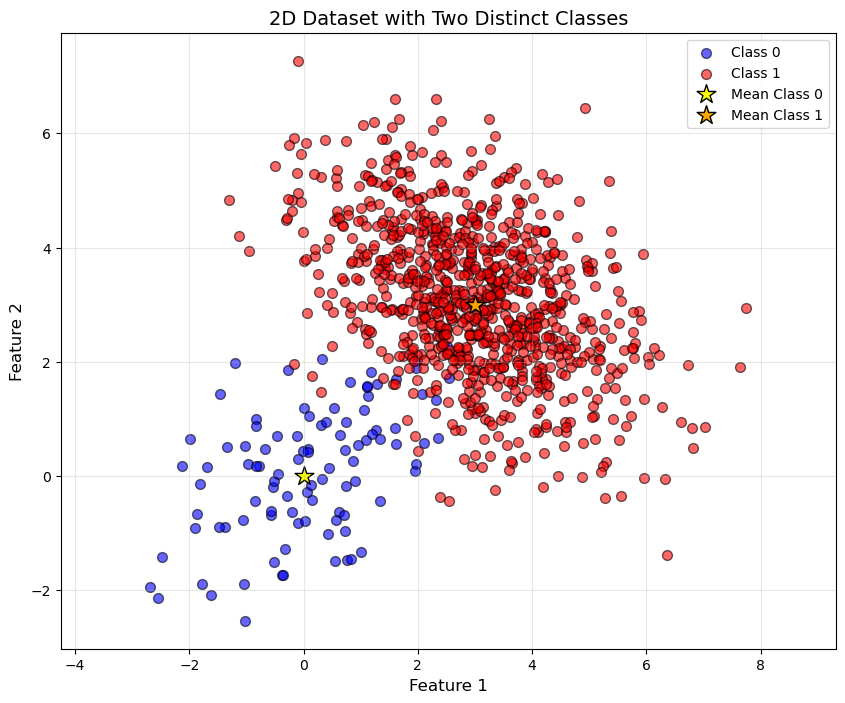


Dataset Statistics:
Class 0 - Mean: [0.13061511 0.15874978]
Class 0 - Std: [1.25518413 1.16844146]
Class 1 - Mean: [2.97754737 3.09977116]
Class 1 - Std: [1.38823676 1.32149633]

Dataset saved to 'two_class_dataset.csv'


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters for the two classes
class_0_samples = 100
class_1_samples = 900

mean_class0 = np.array([0, 0])
cov_class0 = np.array([[2.0, 1.2], 
                       [1.2, 1.8]])

# Class 1: Now closer to class 0
mean_class1 = np.array([3, 3])  # Changed from [5, 5] to [3, 3]
cov_class1 = np.array([[2.0, -0.9], 
                       [-0.9, 1.8]])

# Generate samples
X0 = np.random.multivariate_normal(mean_class0, cov_class0, class_0_samples)
X1 = np.random.multivariate_normal(mean_class1, cov_class1, class_1_samples)

# Create labels (0 and 1)
y0 = np.zeros(class_0_samples, dtype=int)
y1 = np.ones(class_1_samples, dtype=int)

# Combine into single dataset
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

# Create a single array with features and labels
dataset = np.column_stack((X, y))

print(f"Dataset shape: {dataset.shape}")
print(f"Number of class 0 samples: {np.sum(y == 0)}")
print(f"Number of class 1 samples: {np.sum(y == 1)}")
print("\nFirst 5 samples from class 0:")
print(dataset[y == 0][:5])
print("\nFirst 5 samples from class 1:")
print(dataset[y == 1][:5])

# Visualize the dataset
plt.figure(figsize=(10, 8))

plt.scatter(X0[:, 0], X0[:, 1], alpha=0.6, label='Class 0', 
            color='blue', edgecolors='black', s=50)
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.6, label='Class 1', 
            color='red', edgecolors='black', s=50)

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('2D Dataset with Two Distinct Classes', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Add means to plot
plt.scatter(mean_class0[0], mean_class0[1], s=200, marker='*', 
            color='yellow', edgecolors='black', label='Mean Class 0')
plt.scatter(mean_class1[0], mean_class1[1], s=200, marker='*', 
            color='orange', edgecolors='black', label='Mean Class 1')

plt.legend()
plt.show()

# Show statistics
print("\nDataset Statistics:")
print("="*50)
print(f"Class 0 - Mean: {np.mean(X0, axis=0)}")
print(f"Class 0 - Std: {np.std(X0, axis=0)}")
print(f"Class 1 - Mean: {np.mean(X1, axis=0)}")
print(f"Class 1 - Std: {np.std(X1, axis=0)}")

# Optional: Save dataset to CSV
np.savetxt('two_class_dataset.csv', dataset, delimiter=',', 
           header='feature1,feature2,label', comments='', fmt='%.6f,%.6f,%d')
print("\nDataset saved to 'two_class_dataset.csv'")

In [3]:
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, stratify=y,random_state=42)

In [4]:
print(f"y_train.shape={y_train.shape}")
print(f"train_class_0_ratio={np.unique_counts(y_train).counts[0]/y_train.shape}")
print(f"train_class_1_ratio={np.unique_counts(y_train).counts[1]/y_train.shape}")
print("*" * 50)
print(f"y_test.shape:{y_test.shape}")
print(f"test_class_0_ratio={np.unique_counts(y_test).counts[0]/y_test.shape}")
print(f"test_class_1_ratio={np.unique_counts(y_test).counts[1]/y_test.shape}")
print(f"y_test.shape:{y_test.shape}")

y_train.shape=(700,)
train_class_0_ratio=[0.1]
train_class_1_ratio=[0.9]
**************************************************
y_test.shape:(300,)
test_class_0_ratio=[0.1]
test_class_1_ratio=[0.9]
y_test.shape:(300,)


# train classification model

In [5]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# print metrics

In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"accuracy_score(y_test, y_pred)={accuracy}")
print(f"precision_score(y_test, y_pred)={precision}")
print(f"recall_score(y_test, y_pred)={recall}")
print(f"f1_score(y_test, y_pred)={f1}")

accuracy_score(y_test, y_pred)=0.98
precision_score(y_test, y_pred)=0.9852941176470589
recall_score(y_test, y_pred)=0.9925925925925926
f1_score(y_test, y_pred)=0.988929889298893



Method 5: Comprehensive Confusion Matrix


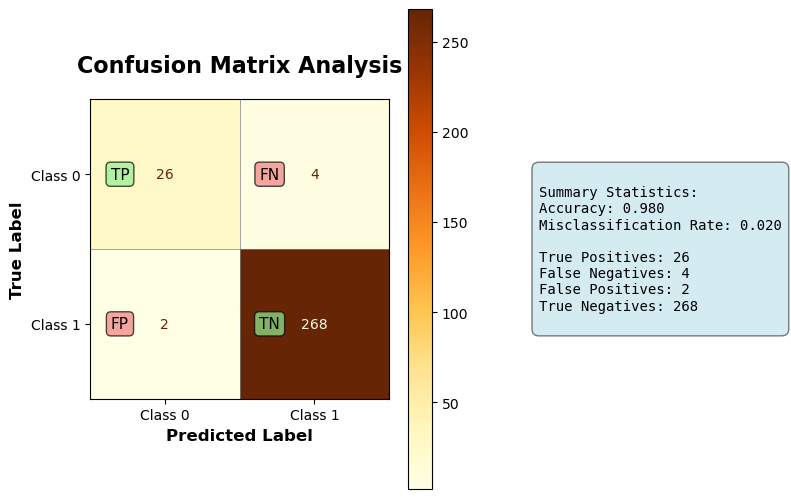

In [7]:
conf_mat = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
# Method 5: Single comprehensive confusion matrix
print("\n" + "="*50)
print("Method 5: Comprehensive Confusion Matrix")
print("="*50)

from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 6))

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat,
                             display_labels=['Class 0', 'Class 1'])

# Plot with customizations
disp.plot(ax=ax, cmap='YlOrBr', values_format='d', colorbar=True,
          xticks_rotation=0)

# Add grid
ax.grid(False)
for i in range(3):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)
    ax.axvline(i - 0.5, color='gray', linewidth=0.5)

# Add titles and labels
ax.set_title('Confusion Matrix Analysis', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')

# Add annotation boxes
ax.text(-0.3, 0, 'TP', fontsize=11, ha='center', va='center', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
ax.text(0.7, 0, 'FN', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))
ax.text(-0.3, 1, 'FP', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))
ax.text(0.7, 1, 'TN', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Add summary statistics
summary_text = f"""
Summary Statistics:
Accuracy: {accuracy:.3f}
Misclassification Rate: {(1-accuracy):.3f}

True Positives: {conf_mat[0, 0]}
False Negatives: {conf_mat[0, 1]}
False Positives: {conf_mat[1, 0]}
True Negatives: {conf_mat[1, 1]}
"""

ax.text(2.5, 0.5, summary_text, fontsize=10, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.5),
        verticalalignment='center')

plt.tight_layout()
plt.show()

In [8]:
y_pred_proba = clf.predict_proba(X_test)[:, 0]


In [9]:
y_pred_proba[:10]

array([4.41363392e-02, 7.75459440e-06, 2.48559915e-04, 7.29133415e-04,
       2.96680193e-03, 2.79933640e-02, 5.83144090e-02, 1.91288729e-05,
       6.88933074e-02, 7.43451707e-03])

In [15]:
num_thresholds = 100
handy_precisions = np.zeros(num_thresholds)
handy_recalls = np.zeros(num_thresholds)

for i in np.arange(num_thresholds):
    y_pred = np.where(y_pred_proba >= i / num_thresholds, 0, 1)
    handy_precisions[i] = precision_score(y_test, y_pred, pos_label=0)
    handy_recalls[i] = recall_score(y_test, y_pred, pos_label=0)


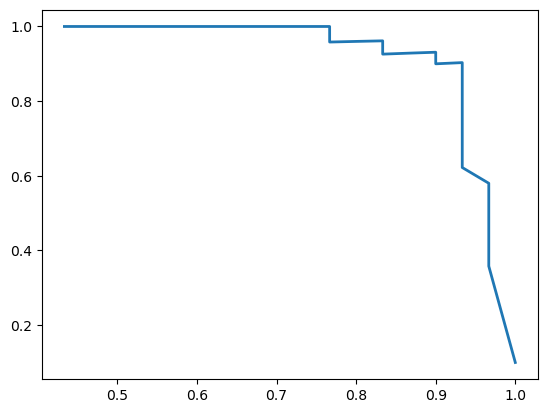

In [16]:
plt.plot(handy_recalls, handy_precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

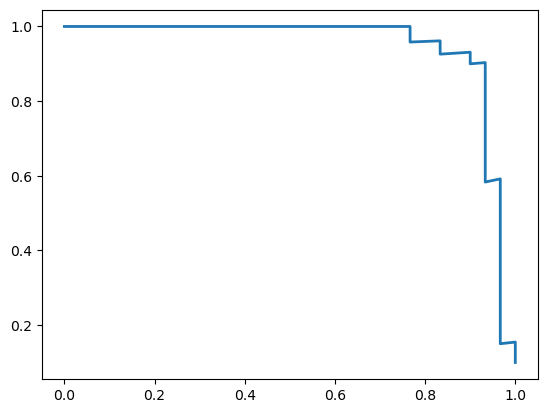

In [17]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba, pos_label=0)
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

C:\Users\Windows 11\AppData\Local\Temp\ipykernel_25900\3837958456.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_score = np.trapz(tprs[::-1], fprs[::-1])  # Reverse for proper AUC


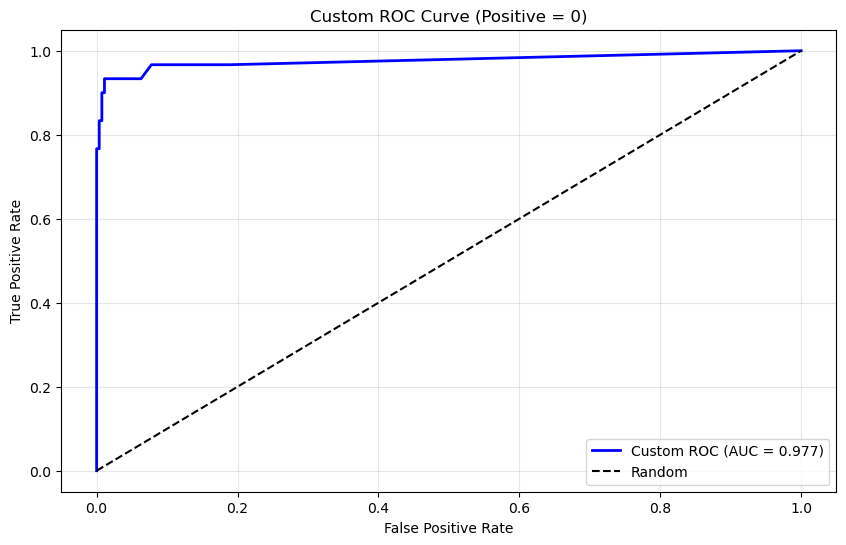

Number of thresholds: 100
AUC: 0.9767
FPR at threshold 0.5: 0.007
TPR at threshold 0.5: 0.867


In [25]:
import numpy as np
import matplotlib.pyplot as plt

def simple_custom_roc(y_true, y_scores, thresholds):
    """
    Simple custom ROC curve calculation for positive class = 0
    """
    tprs = []
    fprs = []
    
    # Sort thresholds for plotting
    thresholds = np.sort(thresholds)
    
    for thresh in thresholds:
        # Predict 0 if score >= threshold, else 1 (positive class = 0)
        y_pred = np.where(y_scores >= thresh, 0, 1)
        
        # Confusion matrix components
        tp = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 1) & (y_pred == 0))
        fn = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 1) & (y_pred == 1))
        
        # Rates
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        tprs.append(tpr)
        fprs.append(fpr)
    
    # Calculate AUC using trapezoidal rule
    auc_score = np.trapz(tprs[::-1], fprs[::-1])  # Reverse for proper AUC
    
    return np.array(fprs), np.array(tprs), auc_score

# Example usage
thresholds = np.linspace(0, 1, 100)
fpr, tpr, auc_score = simple_custom_roc(y_test, y_pred_proba, thresholds)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Custom ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Custom ROC Curve (Positive = 0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Threshold info
idx_05 = np.argmin(np.abs(thresholds - 0.5))
print(f"Number of thresholds: {len(thresholds)}")
print(f"AUC: {auc_score:.4f}")
print(f"FPR at threshold 0.5: {fpr[idx_05]:.3f}")
print(f"TPR at threshold 0.5: {tpr[idx_05]:.3f}")


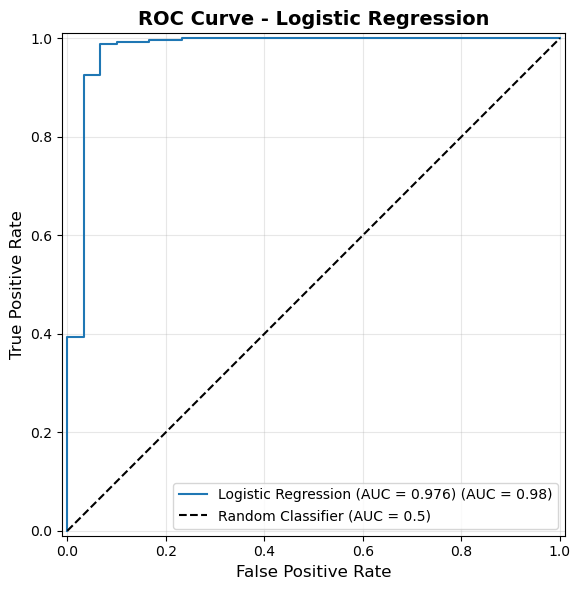

In [22]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = clf.predict_proba(X_test)[:, 0]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test==0, y_pred_proba)

# Plot using RocCurveDisplay
fig, ax = plt.subplots(figsize=(8, 6))

# Method 1A: Using RocCurveDisplay.from_estimator
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, 
                               name=f'Logistic Regression (AUC = {roc_auc:.3f})')

# Add diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()